In [1]:
import scipy.io as sio

import contextlib
from tqdm import tqdm
import joblib
from joblib import Parallel, delayed

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.patches import Rectangle
from pathlib import Path
from scipy import stats
from scipy.interpolate import interp1d
from matplotlib.path import Path as mPath

from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC

from statsmodels.stats.multitest import multipletests
from sklearn.covariance import LedoitWolf

from HPC_2P_analysis.utils.config import (
    get_itr_index,
    index_to_type,
)

from HPC_2P_analysis.utils.loadData import (
    load_screen_data,
)

In [2]:
def extract_ab_ba(data: dict, ana_tt, ana_bt):

    data_AB = []
    data_BA = []
    
    for index in get_itr_index(data, ana_tt, ana_bt):
        
        tt_idx, bt_idx = index
        fr = data["firing"][tt_idx, bt_idx]
        if fr is None:
            continue
        
        tt, _ = index_to_type(data, tt_idx, bt_idx)
        
        if "CAB" in tt or "ACB" in tt or "ABC" in tt:
            data_AB.append(fr)
        elif "CBA" in tt or "BCA" in tt or "BAC" in tt:
            data_BA.append(fr)
        else:
            raise ValueError("Trial type not recognized:", tt)
    
    data_AB = np.concatenate(data_AB, axis=1)
    data_BA = np.concatenate(data_BA, axis=1)

    return data_AB, data_BA


In [3]:
@contextlib.contextmanager
def tqdm_joblib(tqdm_object):
    class TqdmBatchCompletionCallback(joblib.parallel.BatchCompletionCallBack):
        def __call__(self, *args, **kwargs):
            tqdm_object.update(n=self.batch_size)
            return super().__call__(*args, **kwargs)

    old_cb = joblib.parallel.BatchCompletionCallBack
    joblib.parallel.BatchCompletionCallBack = TqdmBatchCompletionCallback
    try:
        yield tqdm_object
    finally:
        joblib.parallel.BatchCompletionCallBack = old_cb
        tqdm_object.close()

In [4]:
def _task_score_decode(task, X_all, labels, perm_labels, splits, C, max_iter):
    """
    task = (shuffle_idx, fold_idx)
    return: (shuffle_idx, fold_idx, scores)  scores shape (n_time,)
    """
    shuffle_idx, fold_idx = task
    y = labels if shuffle_idx < 0 else perm_labels[shuffle_idx]

    train_idx, test_idx = splits[fold_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    n_time = X_all.shape[2]
    scores = np.empty(n_time, dtype=float)

    for t in range(n_time):
        X_t = X_all[:, :, t].T
        X_train, X_test = X_t[train_idx], X_t[test_idx]

        clf = Pipeline([
            ("scaler", StandardScaler()),
            ("svm", LinearSVC(C=C, max_iter=max_iter))
        ])
        clf.fit(X_train, y_train)
        scores[t] = float(clf.score(X_test, y_test))

    return (shuffle_idx, fold_idx, scores)


def decode_and_shuffle(
    data_AB, data_BA,
    n_splits=5, n_repeats=10,
    n_shuffles=500,
    n_jobs=64,
    random_state=0,
    backend="threading",
    C=1.0,
    max_iter=20000,
):
    rng = np.random.RandomState(random_state)

    neurons, n_AB, n_time = data_AB.shape
    _, n_BA, _ = data_BA.shape

    X_all = np.concatenate([data_AB, data_BA], axis=1)  # (neurons, n_trials, n_time)
    labels = np.concatenate([
        np.ones(n_AB, dtype=int),
        np.zeros(n_BA, dtype=int)
    ])  # (n_trials,)

    n_trials = labels.size

    # repeated stratified CV (keeps class ratios)
    cv = RepeatedStratifiedKFold(
        n_splits=n_splits,
        n_repeats=n_repeats,
        random_state=random_state
    )
    splits = list(cv.split(np.zeros(n_trials), labels))
    n_folds = len(splits)

    # pre-generate permuted labels
    perm_labels = np.empty((n_shuffles, n_trials), dtype=int)
    for i in range(n_shuffles):
        perm_labels[i] = rng.permutation(labels)

    tasks = []
    for fold_idx in range(n_folds):
        tasks.append((-1, fold_idx))
    for i_shuf in range(n_shuffles):
        for fold_idx in range(n_folds):
            tasks.append((i_shuf, fold_idx))

    total_tasks = len(tasks)

    pbar = tqdm(total=total_tasks, desc="Shuffle & Decode", dynamic_ncols=True)
    with tqdm_joblib(pbar):
        results = Parallel(n_jobs=n_jobs, backend=backend, inner_max_num_threads=1, batch_size="auto")(
            delayed(_task_score_decode)(task, X_all, labels, perm_labels, splits, C, max_iter)
            for task in tasks
        )

    # aggregate
    scores_real = np.zeros((n_folds, n_time), dtype=float)
    scores_shuffle = np.zeros((n_shuffles, n_folds, n_time), dtype=float)

    for shuf_idx, fold_idx, scores in results:
        if shuf_idx < 0:
            scores_real[fold_idx, :] = scores
        else:
            scores_shuffle[shuf_idx, fold_idx, :] = scores

    mean_acc = np.mean(scores_real, axis=0)
    sem_acc  = np.std(scores_real, axis=0, ddof=1) / np.sqrt(n_folds)

    # shuffle: take mean across folds for each shuffle
    shuffle_means = np.mean(scores_shuffle, axis=1)  # (n_shuffles, n_time)
    shuffle_lower = np.percentile(shuffle_means, 2.5, axis=0)
    shuffle_upper = np.percentile(shuffle_means, 97.5, axis=0)

    # cluster stats (1D over time): same as your original
    sig_mask = mean_acc > shuffle_upper
    clusters = []
    current = None
    for i, v in enumerate(sig_mask):
        if v:
            if current is None:
                current = [i, i]
            else:
                current[1] = i
        else:
            if current is not None:
                clusters.append(tuple(current))
                current = None
    if current:
        clusters.append(tuple(current))

    real_cluster_stats = []
    for start_idx, end_idx in clusters:
        stat = np.sum(mean_acc[start_idx:end_idx+1] - shuffle_upper[start_idx:end_idx+1])
        real_cluster_stats.append((start_idx, end_idx, stat))

    null_cluster_stats = []
    for i in range(n_shuffles):
        perm = shuffle_means[i]
        perm_mask = perm > shuffle_upper
        c = None
        for j, v in enumerate(perm_mask):
            if v:
                if c is None:
                    c = [j, j]
                else:
                    c[1] = j
            else:
                if c is not None:
                    mass = np.sum(perm[c[0]:c[1]+1] - shuffle_upper[c[0]:c[1]+1])
                    null_cluster_stats.append(mass)
                    c = None
        if c:
            mass = np.sum(perm[c[0]:c[1]+1] - shuffle_upper[c[0]:c[1]+1])
            null_cluster_stats.append(mass)

    null_cluster_stats = np.array(null_cluster_stats, dtype=float)

    cluster_signif = []
    for start_idx, end_idx, stat in real_cluster_stats:
        pval = (np.sum(null_cluster_stats >= stat) + 1) / (len(null_cluster_stats) + 1)
        cluster_signif.append((start_idx, end_idx, pval))

    return mean_acc, sem_acc, shuffle_lower, shuffle_upper, cluster_signif


def _task_tgm_chunk(task, X, y, splits, time_idx, C, max_iter):
    """
    task = (fold_idx, chunk_start, chunk_end)
    X: (n_trials, n_neurons, n_time)
    time_idx: (T,) list of used time indices
    return: (fold_idx, chunk_start, rows) rows shape (chunk_len, T)
    """
    fold_idx, cs, ce = task
    train_idx, test_idx = splits[fold_idx]

    y_train = y[train_idx]
    y_test  = y[test_idx]
    T = len(time_idx)

    # test data for all t_test once: (T, n_test, n_neurons)
    X_test_all = X[test_idx][:, :, time_idx]          # (n_test, n_neurons, T)
    X_test_all = np.transpose(X_test_all, (2, 0, 1))  # (T, n_test, n_neurons)

    rows = np.empty((ce - cs, T), dtype=float)

    for ii, t_train in enumerate(time_idx[cs:ce]):
        # TRAIN at one time
        X_train = X[train_idx, :, t_train]  # (n_train, n_neurons)

        # fit scaler ONLY on training to avoid leakage :contentReference[oaicite:5]{index=5}
        scaler = StandardScaler(with_mean=True, with_std=True)
        X_train_z = scaler.fit_transform(X_train)

        mean = scaler.mean_
        scale = scaler.scale_.copy()
        scale[scale == 0] = 1.0

        clf = LinearSVC(C=C, max_iter=max_iter)
        clf.fit(X_train_z, y_train)

        w = clf.coef_.ravel()
        b = float(clf.intercept_[0])

        # standardize all test times in one shot: (T, n_test, n_neurons)
        Xz = (X_test_all - mean[None, None, :]) / scale[None, None, :]

        # decision scores: (T, n_test)
        scores = np.tensordot(Xz, w, axes=([2], [0])) + b

        pred = (scores > 0).astype(int)
        acc  = (pred == y_test[None, :]).mean(axis=1)  # (T,)
        rows[ii, :] = acc

    return fold_idx, cs, rows


def temporal_generalization(
    data_AB, data_BA,
    n_splits=5, n_repeats=10,
    n_jobs=64,
    random_state=0,
    backend="threading",
    C=1.0,
    max_iter=20000,
    chunk_size=10,
):
    data_AB = np.asarray(data_AB, dtype=float)
    data_BA = np.asarray(data_BA, dtype=float)
    n_neurons, n_AB, n_time = data_AB.shape
    _, n_BA, n_time2 = data_BA.shape
    if n_time2 != n_time:
        raise ValueError("data_AB and data_BA must have same n_time")

    X_all = np.concatenate([data_AB, data_BA], axis=1)  # (n_neurons, n_trials, n_time)
    y = np.concatenate([np.zeros(n_AB, int), np.ones(n_BA, int)])
    n_trials = y.size

    # reshape to (n_trials, n_neurons, n_time)
    X = X_all.transpose(1, 0, 2)

    time_idx = np.arange(0, n_time, dtype=int)
    T = len(time_idx)

    cv = RepeatedStratifiedKFold(
        n_splits=n_splits,
        n_repeats=n_repeats,
        random_state=random_state
    )
    splits = list(cv.split(np.zeros(n_trials), y))
    n_folds = len(splits)

    # tasks: (fold, chunk_start, chunk_end)
    tasks = []
    for fold_idx in range(n_folds):
        for cs in range(0, T, chunk_size):
            ce = min(cs + chunk_size, T)
            tasks.append((fold_idx, cs, ce))

    pbar = tqdm(total=len(tasks), desc="TGM", dynamic_ncols=True)
    with tqdm_joblib(pbar):
        results = Parallel(n_jobs=n_jobs, backend=backend)(
            delayed(_task_tgm_chunk)(task, X, y, splits, time_idx, C, max_iter)
            for task in tasks
        )

    # aggregate across folds using sum & sumsq
    sum_mat = np.zeros((T, T), dtype=float)
    sumsq_mat = np.zeros((T, T), dtype=float)

    for fold_idx, cs, rows in results:
        ce = cs + rows.shape[0]
        sum_mat[cs:ce, :] += rows
        sumsq_mat[cs:ce, :] += rows * rows

    tgm_mean = sum_mat / n_folds

    if n_folds > 1:
        var = (sumsq_mat - (sum_mat * sum_mat) / n_folds) / (n_folds - 1)
        var = np.maximum(var, 0.0)
        tgm_sem = np.sqrt(var / n_folds)
    else:
        tgm_sem = np.zeros_like(tgm_mean)

    return tgm_mean, tgm_sem


# mean_acc, sem_acc, shuf_lo, shuf_hi, clusters = decode_and_shuffle(
#     data_AB, data_BA,
#     n_splits=5, n_repeats=10,
#     n_shuffles=100,
#     n_jobs=12,
#     backend="threading",   # or "loky"
#     random_state=0
# )
#
# tgm_mean, tgm_sem, time_idx = temporal_generalization_no_perm(
#     data_AB, data_BA,
#     n_splits=5, n_repeats=10,
#     n_jobs=12,
#     backend="threading",
#     time_stride=1,
#     chunk_size=10
# )


In [5]:
def plot_decoding_with_zones(data: dict, mean_acc, sem_acc, shuffle_lower, shuffle_upper, cluster_signif, space_unit=2.0):

    n_time = len(mean_acc)
    X = np.arange(n_time)

    zones_color = {
        1: "#1f77b4",
        3: "#1f77b4",
    }
    acc_color = "#2ca02c"


    plt.figure(figsize=(6, 3))
    ax = plt.gca()

    # mean + sem
    ax.plot(X, mean_acc, color=acc_color)
    ax.fill_between(X, mean_acc - sem_acc, mean_acc + sem_acc, color=acc_color, alpha=0.4)

    # shuffle band
    ax.fill_between(X, shuffle_lower, shuffle_upper, color="gray", alpha=0.4)

    # chance line
    ax.axhline(0.5, linestyle="--", color="k")

    # cluster significance highlight
    for start, end, p in cluster_signif:
        if p < 0.05:
            ax.axvspan(start, end, facecolor="black", alpha=0.2)

    # zones background (horizontal bars)
    x0, x1 = ax.get_xlim()
    eps = 0.002 * (x1 - x0)
    h_frac = 0.05

    zones = data["zones"]

    for zi, row in enumerate(zones):

        if zi not in zones_color: continue

        start_x = np.floor(row[0])
        end_x   = np.ceil(row[1])

        ax.axvline(start_x, linestyle="--", color="k", linewidth=1)
        ax.axvline(end_x,   linestyle="--", color="k", linewidth=1)

        color_zone = zones_color[zi]

        # rect = Rectangle(
        #     (start_x - eps, 1.0 - h_frac),
        #     end_x - start_x + 2*eps, h_frac,
        #     transform=ax.get_xaxis_transform(),
        #     facecolor=color_zone,
        #     edgecolor="none",
        #     clip_on=False,
        #     zorder=6,
        # )
        # ax.add_patch(rect)

    # aesthetics
    ax.set_ylim(0, 1.02)
    ax.set_xlabel("Position (cm)", fontsize=12)
    ax.set_ylabel("Accuracy", fontsize=12)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.xaxis.set_ticks_position('bottom')
    ax.yaxis.set_ticks_position('left')
    ax.xaxis.set_major_formatter(
        mticker.FuncFormatter(lambda x, pos: f"{x * space_unit:g}")
    )
    ax.tick_params(labelsize=12)
    plt.tight_layout()
    plt.show()


def plot_tgm_heatmap(
    data: dict,
    tgm_mean: np.ndarray,
    *,
    vmin: float | None = None,
    vmax: float | None = None,
    show_diag: bool = True,
    show_zones: bool = True,
    space_unit: float = 2.0,
):

    tgm_mean = np.asarray(tgm_mean, dtype=float)
    if tgm_mean.ndim != 2 or tgm_mean.shape[0] != tgm_mean.shape[1]:
        raise ValueError("tgm_mean must be a square 2D array (T, T)")
    T = tgm_mean.shape[0]

    time_idx = np.arange(T, dtype=float)

    coord = time_idx
    xlabel = "Test position (cm)"
    ylabel = "Train position (cm)"

    if T > 1:
        d = float(coord[1] - coord[0])
    else:
        d = 1.0
    extent = [coord[0] - d/2, coord[-1] + d/2, coord[0] - d/2, coord[-1] + d/2]

    chance = 0.5
    if vmin is None or vmax is None:
        dev = np.nanmax(np.abs(tgm_mean - chance))
        if not np.isfinite(dev) or dev == 0:
            dev = 0.05
        if vmin is None:
            vmin = chance - dev
        if vmax is None:
            vmax = chance + dev
    
    fig = plt.figure(figsize=(6, 5))
    ax = fig.gca()
    title = "Temporal generalization"
    cbar_labels = "Score"

    cmap = "viridis"
    im = ax.imshow(
        tgm_mean,
        origin="lower",
        extent=extent,
        aspect="auto",
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
        interpolation="nearest",
    )

    ax.set_title(title, fontsize=13)
    ax.set_xlabel(xlabel, fontsize=12)
    ax.set_ylabel(ylabel, fontsize=12)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.xaxis.set_ticks_position("bottom")
    ax.yaxis.set_ticks_position("left")
    ax.xaxis.set_major_formatter(
            mticker.FuncFormatter(lambda x, pos: f"{x * space_unit:g}")
    )
    ax.yaxis.set_major_formatter(
            mticker.FuncFormatter(lambda x, pos: f"{x * space_unit:g}")
    )

    if show_diag:
        ax.plot([coord[0], coord[-1]], [coord[0], coord[-1]], linestyle="--", linewidth=0.8, color="k", alpha=0.6)

    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label(cbar_labels, fontsize=11)

    zones = data["zones"]
    zones_color = {
        1: "#1f77b4",
        3: "#1f77b4",
    }

    if show_zones and zones is not None and len(zones) > 0:

        for zi, row in enumerate(zones):

            if zi not in zones_color: continue

            start_x = row[0]
            end_x   = row[1]

            ax.axvline(start_x, linestyle="--", color="k", linewidth=0.8)
            ax.axvline(end_x,   linestyle="--", color="k", linewidth=0.8)
            ax.axhline(start_x, linestyle="--", color="k", linewidth=0.8)
            ax.axhline(end_x,   linestyle="--", color="k", linewidth=0.8)

    plt.tight_layout()
    plt.show()

(1154, 72, 160) (1154, 69, 160)


Shuffle & Decode: 100%|██████████| 25050/25050 [18:00<00:00, 23.18it/s]


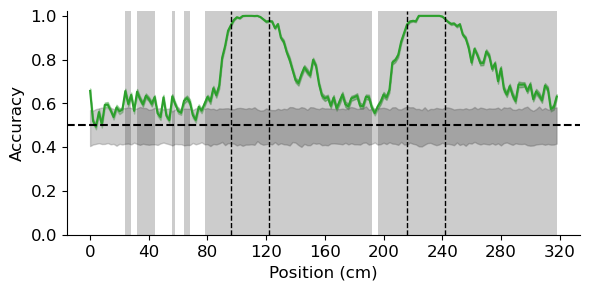

TGM:   8%|▊         | 64/800 [00:05<01:07, 10.87it/s]


KeyboardInterrupt: 

In [ ]:
# file_path = "../../../data/HPC_2p/screen/HP01/HP01_2024-12-14_pattern_screen.pkl"

# data = load_screen_data(
#     file_path,
#     screen_mode="masked",
# )
# data_AB, data_BA = extract_ab_ba(data, ana_tt=["*"], ana_bt=["*"])

# print(data_AB.shape, data_BA.shape)

# mean_acc, sem_acc, shuf_lo, shuf_hi, clusters = decode_and_shuffle(data_AB, data_BA, backend="loky")
# plot_decoding_with_zones(data, mean_acc, sem_acc, shuf_lo, shuf_hi, clusters)
# tgm_mean, _ = temporal_generalization(data_AB, data_BA)
# plot_tgm_heatmap(data, tgm_mean, vmin=0.2, vmax=0.8)

In [ ]:
# file_path = "../../data/HPC_2p/HP07/neuro_type_saveHP07_17_2025-03-11.mat"

# data = load_screen_data(
#     file_path,
#     screen_mode="masked",
# )
# data_AB, data_BA = extract_ab_ba(data, ana_tt=["*"], ana_bt=["*"])

# print(data_AB.shape, data_BA.shape)

# mean_acc, sem_acc, shuf_lo, shuf_hi, clusters = decode_and_shuffle(data_AB, data_BA, backend="loky")
# plot_decoding_with_zones(data, mean_acc, sem_acc, shuf_lo, shuf_hi, clusters)
# tgm_mean, _ = temporal_generalization(data_AB, data_BA)
# plot_tgm_heatmap(data, tgm_mean, vmin=0.2, vmax=0.8)

In [ ]:
def _clamp_slice(s: int, e: int, T: int) -> tuple[int, int]:
    s = int(s); e = int(e)
    s = max(0, min(s, T))
    e = max(0, min(e, T))
    return s, e

def extract_begin_position(
    data: dict,
    ana_tt: list,
    ana_bt: list,
):
    s1 = 0
    e1 = 10
    
    data_AB_list = []
    data_BA_list = []
    
    for index in get_itr_index(data, ana_tt, ana_bt):
        
        tt_idx, bt_idx = index
        fr = data["firing"][tt_idx, bt_idx]
        if fr is None:
            continue
        
        tt, _ = index_to_type(data, tt_idx, bt_idx)

        T = fr.shape[2]
        s1c, e1c = _clamp_slice(s1, e1, T)
        if (e1c <= s1c):
            continue

        fr_seg = fr[:, :, s1c:e1c]

        if ("CAB" in tt) or ("ACB" in tt) or ("ABC" in tt):
            data_AB_list.append(fr_seg)
        elif ("CBA" in tt) or ("BCA" in tt) or ("BAC" in tt):
            data_BA_list.append(fr_seg)
        else:
            raise ValueError(f"Trial type not recognized: {tt}")

    if (len(data_AB_list) == 0) or (len(data_BA_list) == 0):
        return None, None

    data_AB = np.concatenate(data_AB_list, axis=1)  # (neurons, nAB, L)
    data_BA = np.concatenate(data_BA_list, axis=1)  # (neurons, nBA, L)
    return data_AB, data_BA
        

def extract_ab_position(
    data: dict,
    ana_tt: list,
    ana_bt: list,
    *,
    extend_cm: float = 10.0,
):
    zones = data["zones"]
    zone1_idx = 1
    zone2_idx = 3

    # s1 = int(np.floor((zones[zone1_idx][0] - extend_cm)))
    # e1 = int(np.ceil ((zones[zone1_idx][1] + extend_cm)))
    # s2 = int(np.floor((zones[zone2_idx][0] - extend_cm)))
    # e2 = int(np.ceil ((zones[zone2_idx][1] + extend_cm)))
    
    s1 = int(np.floor((zones[zone1_idx][0])))
    e1 = int(np.ceil ((zones[zone1_idx + 1][0])))
    s2 = int(np.floor((zones[zone2_idx][0])))
    e2 = int(np.ceil ((zones[zone2_idx + 1][0])))

    data_AB_list = []
    data_BA_list = []
    
    for index in get_itr_index(data, ana_tt, ana_bt):
        
        tt_idx, bt_idx = index
        fr = data["firing"][tt_idx, bt_idx]
        if fr is None:
            continue
        
        tt, _ = index_to_type(data, tt_idx, bt_idx)

        T = fr.shape[2]
        s1c, e1c = _clamp_slice(s1, e1, T)
        s2c, e2c = _clamp_slice(s2, e2, T)
        if (e1c <= s1c) or (e2c <= s2c):
            continue

        seg1 = fr[:, :, s1c:e1c]
        seg2 = fr[:, :, s2c:e2c]
        fr_seg = np.concatenate([seg1, seg2], axis=2)  # (neurons, trials, L)

        if ("CAB" in tt) or ("ACB" in tt) or ("ABC" in tt):
            data_AB_list.append(fr_seg)
        elif ("CBA" in tt) or ("BCA" in tt) or ("BAC" in tt):
            data_BA_list.append(fr_seg)
        else:
            raise ValueError(f"Trial type not recognized: {tt}")

    if (len(data_AB_list) == 0) or (len(data_BA_list) == 0):
        return None, None

    data_AB = np.concatenate(data_AB_list, axis=1)  # (neurons, nAB, L)
    data_BA = np.concatenate(data_BA_list, axis=1)  # (neurons, nBA, L)
    return data_AB, data_BA


# =========================
# Fisher-vector + permutation + FDR
# =========================

def time_bin_mean(fr_seg, bin_size: int | None):
    if bin_size is None or bin_size <= 1:
        return fr_seg
    L = fr_seg.shape[2]
    L2 = (L // bin_size) * bin_size
    if L2 <= 0:
        return fr_seg
    x = fr_seg[:, :, :L2]
    x = x.reshape(x.shape[0], x.shape[1], L2 // bin_size, bin_size).mean(axis=3)
    return x


def _one_neuron_fisher_diag_perm(Xn_all, y, M, n_pos, n_neg, ridge=1e-6, eps=1e-12):
    """
    Xn_all: (n_trials, L)
    y: (n_trials,)
    M: (n_perm, n_trials) float32
    """
    X = Xn_all.astype(np.float64, copy=False)
    X2 = X * X

    total_sum = X.sum(axis=0)      # (L,)
    total_sum_sq = X2.sum(axis=0)  # (L,)

    Xpos = X[y == 1]
    Xneg = X[y == 0]
    if Xpos.shape[0] < 2 or Xneg.shape[0] < 2:
        return 0.0, 1.0

    mu_pos = Xpos.mean(axis=0)
    mu_neg = Xneg.mean(axis=0)
    delta = mu_pos - mu_neg

    var_pos = Xpos.var(axis=0, ddof=1)
    var_neg = Xneg.var(axis=0, ddof=1)
    sw = var_pos + var_neg + ridge
    stat_obs = float(np.sum((delta * delta) / (sw + eps)))

    # permutation：pos_sum = M @ X => (n_perm, L)
    pos_sum = M @ X
    pos_sum_sq = M @ X2

    neg_sum = total_sum[None, :] - pos_sum
    neg_sum_sq = total_sum_sq[None, :] - pos_sum_sq

    pos_mean = pos_sum / n_pos
    neg_mean = neg_sum / n_neg
    delta_p = pos_mean - neg_mean

    pos_var = (pos_sum_sq - (pos_sum * pos_sum) / n_pos) / max(n_pos - 1, 1)
    neg_var = (neg_sum_sq - (neg_sum * neg_sum) / n_neg) / max(n_neg - 1, 1)
    pos_var = np.maximum(pos_var, 0.0)
    neg_var = np.maximum(neg_var, 0.0)

    sw_p = pos_var + neg_var + ridge
    stat_null = np.sum((delta_p * delta_p) / (sw_p + eps), axis=1)

    p = (1.0 + np.sum(stat_null >= stat_obs)) / (len(stat_null) + 1.0)
    return stat_obs, p


def _fisher_vector_stat_lw(X0, X1, ridge=1e-6):
    mu0 = X0.mean(axis=0)
    mu1 = X1.mean(axis=0)
    delta = mu1 - mu0

    R0 = X0 - mu0
    R1 = X1 - mu1
    R = np.vstack([R0, R1])  # pooled residuals

    lw = LedoitWolf(assume_centered=True).fit(R)
    Sw = lw.covariance_.copy()
    L = Sw.shape[0]
    Sw.flat[::L + 1] += ridge

    z = np.linalg.solve(Sw, delta)
    return float(delta @ z)


def _one_neuron_fisher_lw_perm(Xn_all, y, perms, ridge=1e-6):
    X0 = Xn_all[y == 0]
    X1 = Xn_all[y == 1]
    if X0.shape[0] < 2 or X1.shape[0] < 2:
        return 0.0, 1.0

    obs = _fisher_vector_stat_lw(X0, X1, ridge=ridge)

    null = np.empty(len(perms), dtype=float)
    for i, yp in enumerate(perms):
        X0p = Xn_all[yp == 0]
        X1p = Xn_all[yp == 1]
        null[i] = _fisher_vector_stat_lw(X0p, X1p, ridge=ridge)

    p = (1.0 + np.sum(null >= obs)) / (len(null) + 1.0)
    return obs, p


def count_sig_neurons_fisher_vector(
    file_path,
    ana_tt,
    ana_bt,
    *,
    screen_mode: str = "masked",
    position_type="ab", # "ab" or "begin"
    extend_cm=10.0,
    n_perm=2000,
    alpha=0.05,
    seed=0,
    cov="diag",        # "diag" or "lw"
    ridge=1e-6,
    time_bin=5,        # 5~10
    n_jobs=8,
    backend="threading",
):
    rng = np.random.RandomState(seed)

    data = load_screen_data(
        file_path,
        screen_mode=screen_mode,
    )
    
    if position_type == "ab":
        data_AB, data_BA = extract_ab_position(data, ana_tt, ana_bt, extend_cm=extend_cm)
    elif position_type == "begin":
        data_AB, data_BA = extract_begin_position(data, ana_tt, ana_bt)
    else:
        raise ValueError("position_type must be 'ab' or 'begin'")
    
    if data_AB is None:
        return {"n_sig": 0, "n_neuron": 0, "p": None, "q": None, "sig_neuron_ids": []}

    data_AB = time_bin_mean(data_AB, time_bin)
    data_BA = time_bin_mean(data_BA, time_bin)

    n_neuron = data_AB.shape[0]
    nAB = data_AB.shape[1]
    nBA = data_BA.shape[1]

    y = np.concatenate([np.zeros(nAB, int), np.ones(nBA, int)])
    n_trials = y.size
    n_pos = int(y.sum())
    n_neg = int(n_trials - n_pos)
    if n_pos < 2 or n_neg < 2:
        return {"n_sig": 0, "n_neuron": n_neuron, "p": None, "q": None, "sig_neuron_ids": []}

    perm_idx = np.array([rng.permutation(n_trials) for _ in range(n_perm)], dtype=np.int32)
    y_perm = y[perm_idx]
    M = (y_perm == 1).astype(np.float32)

    perms = [y_perm[i, :] for i in range(n_perm)]

    def _task(neuron_id: int):
        Xn_all = np.vstack([data_AB[neuron_id, :, :], data_BA[neuron_id, :, :]])  # (n_trials, L)
        if cov == "diag":
            return _one_neuron_fisher_diag_perm(Xn_all, y, M, n_pos, n_neg, ridge=ridge)
        elif cov == "lw":
            return _one_neuron_fisher_lw_perm(Xn_all, y, perms, ridge=ridge)
        else:
            raise ValueError("cov must be 'diag' or 'lw'")

    with tqdm_joblib(tqdm(total=n_neuron, desc=f"neurons (fisher-{cov})",
                            leave=False, dynamic_ncols=True)):
        results = Parallel(n_jobs=n_jobs, backend=backend)(
            delayed(_task)(n) for n in range(n_neuron)
        )

    stat_obs = np.array([r[0] for r in results], dtype=float)
    pvals = np.array([r[1] for r in results], dtype=float)

    rej, qvals, _, _ = multipletests(pvals, alpha=alpha, method="fdr_bh")

    # Collect significant neuron IDs
    sig_neuron_ids = data["cell_ids"][rej]  # Extract the IDs of significant neurons
    
    file_info = data.get("file_info", {})

    return {
        "n_sig": int(rej.sum()),
        "n_neuron": n_neuron,
        "p": pvals,
        "q": qvals,
        "stat": stat_obs,
        "sig_mask": rej,
        "sig_neuron_ids": sig_neuron_ids.tolist(),  # Return the list of significant neuron IDs
        "cov": cov,
        "time_bin": time_bin,
        "mouse_id": file_info.get("mouse_id"),
        "task_type": file_info.get("task_type"),
        "reward_mode": file_info.get("reward_mode"),
        "file_path": str(file_path),
    }
    

In [ ]:
def test_max_firing_at_ab(
    file_path,
    ana_tt,
    ana_bt,
    *,
    screen_mode: str = "masked",
    extend_cm=0.0,
):
    data = load_screen_data(
        file_path,
        screen_mode=screen_mode,
    )
    
    zones = data["zones"]
    zone1_idx = 1
    zone2_idx = 3

    # s1 = int(np.floor((zones[zone1_idx][0] - extend_cm)))
    # e1 = int(np.ceil ((zones[zone1_idx][1] + extend_cm)))
    # s2 = int(np.floor((zones[zone2_idx][0] - extend_cm)))
    # e2 = int(np.ceil ((zones[zone2_idx][1] + extend_cm)))
    s1 = int(np.floor((zones[zone1_idx][0])))
    e1 = int(np.ceil ((zones[zone1_idx + 1][0])))
    s2 = int(np.floor((zones[zone2_idx][0])))
    e2 = int(np.ceil ((zones[zone2_idx + 1][0])))
    
    # all_rejs = []

    # for index in get_itr_index(data, ana_tt, ana_bt):
        
    #     tt_idx, bt_idx = index
    #     fr = data["firing"][tt_idx, bt_idx]
        
    #     if fr is None:
    #         continue

    #     fr = np.mean(fr, axis=1)  # average over trials: (neurons, time)
    #     whole_range_max = fr.max(axis=1)  # (neurons,)

    #     seg1_data = fr[:, s1:e1]
    #     seg2_data = fr[:, s2:e2]
    #     seg_max = np.maximum(seg1_data.max(axis=1), seg2_data.max(axis=1))  # (neurons,)

    #     rejs = (whole_range_max < 2 * seg_max)
            
    #     all_rejs.append(rejs)
        
    # all_rejs = np.array(all_rejs, dtype=bool)
    # final_rej = np.any(all_rejs, axis=0) # (neurons,)
    
    all_fr = []
    
    for index in get_itr_index(data, ana_tt, ana_bt):
        
        tt_idx, bt_idx = index
        fr = data["firing"][tt_idx, bt_idx]
        
        if fr is None:
            continue

        all_fr.append(fr)
        
    all_fr = np.concatenate(all_fr, axis=1)  # (neurons, n_trials, time)
    all_fr = np.mean(all_fr, axis=1)  # average over trials:
    whole_range_max = all_fr.max(axis=1)  # (neurons,)
    seg1_data = all_fr[:, s1:e1]
    seg2_data = all_fr[:, s2:e2]
    seg_max = np.maximum(seg1_data.max(axis=1), seg2_data.max(axis=1))  # (neurons,)
    final_rej = (whole_range_max < 1.05 * seg_max)
    
    neuron_ids = data["cell_ids"][final_rej]
    
    return neuron_ids
        

In [ ]:
# file_path = "../../data/HPC_2p/HP02/neuro_type_saveHP02_2_2024-12-29.mat"

# res_flw1 = count_sig_neurons_fisher_vector(
#     file_path, ana_tt=["*"], ana_bt=["*"],
#     position_type="begin",
#     cov="lw", time_bin=5,
#     n_perm=1000, alpha=0.1,
#     n_jobs=10, backend="threading"
# )

# print(np.where(res_flw1["sig_mask"])[0])

In [ ]:
# file_path = "../../data/HPC_2p/HP02/neuro_type_saveHP02_1_2024-12-23.mat"
# extend_cm = 0

# res_flw1 = count_sig_neurons_fisher_vector(
#     file_path, ana_tt=["*"], ana_bt=["*"],
#     cov="lw", time_bin=5, extend_cm=extend_cm,
#     n_perm=1000, alpha=0.01,
#     n_jobs=10, backend="threading"
# )

# mf_ids1 = test_max_firing_at_ab(
#     file_path, ana_tt=["*"], ana_bt=["Correct"],
#     extend_cm=extend_cm,
# )

# intersec1 = list(set(res_flw1['sig_neuron_ids']) & set(mf_ids1))


# print(f"Intersection of significant neurons neurons:{len(res_flw1['sig_neuron_ids'])} / {res_flw1['n_neuron']}")
# print(f"Intersection of significant neurons and max-firing neurons:{len(intersec1)} / {res_flw1['n_neuron']}")


In [ ]:
# file_path = "../../data/HPC_2p/HP02/neuro_type_saveHP02_2_2024-12-29.mat"
# extend_cm = 0

# res_flw2 = count_sig_neurons_fisher_vector(
#     file_path, ana_tt=["*"], ana_bt=["*"],
#     cov="lw", time_bin=5, extend_cm=extend_cm,
#     n_perm=1000, alpha=0.01,
#     n_jobs=10, backend="threading"
# )

# mf_ids2 = test_max_firing_at_ab(
#     file_path, ana_tt=["*"], ana_bt=["*"],
#     extend_cm=extend_cm,
# )
# intersec2 = list(set(res_flw2['sig_neuron_ids']) & set(mf_ids2))

# print(f"Intersection of significant neurons neurons:{len(res_flw2['sig_neuron_ids'])} / {res_flw2['n_neuron']}")
# print(f"Intersection of significant neurons and max-firing neurons:{len(intersec2)} / {res_flw2['n_neuron']}")